In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import re
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Read Dataset
df= pd.read_csv('D:/CIS545_Proj/dataset/train.csv')

C:\Users\asus\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3185: DtypeWarning: Columns (26) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [3]:
#Drop duplicate rows
df.drop_duplicates(inplace=True)

#Drop unimportant columns
df = df.drop(['ID','Customer_ID','Month','Name','SSN', 'Type_of_Loan', 'Changed_Credit_Limit', 'Monthly_Inhand_Salary'], axis = 1)

#Correct the Age column by addressing anomalies: rows with invalid values such as ages less than 1, greater than 100, or containing non-numeric characters
df['Age'] = df['Age'].str.replace(r'\D', '', regex=True).astype(int)
df = df[df['Age']>0][df['Age']< 100]

#Replace the '_______' value in the Occupation field with Other
df['Occupation'] = df['Occupation'].replace('_______', 'Other')

#Convert the Annual_income column to float type
df['Annual_Income'] = df['Annual_Income'].str.replace('_', '').astype(float)

#Correct the Num_Bank_Accounts with negative value and huge value:
df = df[df['Num_Bank_Accounts']>=0]

#Convert Num_of_Loan to int type and correct it
df['Num_of_Loan'] = df['Num_of_Loan'].str.replace('_', '').astype(int)
df = df[df['Num_of_Loan']>0][df['Num_of_Loan']<100]

#Covert Num_of_Delayed_Payment to int type and correct it
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].str.replace('_', '').dropna().astype(int)
df = df[df['Num_of_Delayed_Payment']>0]

#Covert Outstanding_Debt to int type and correct it
df['Outstanding_Debt'] = df['Outstanding_Debt'].str.replace('_', '').astype(float)

#Convert Credit_History_Age to a float number of days
def age2days(text,years=0,months=0):
    years_match = re.search(r'(\d+) Years?', text, re.IGNORECASE)
    months_match = re.search(r'(\d+) Months?', text, re.IGNORECASE)
    days_in_year = 365.25
    days_in_month = 30.44
    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0
    return (years * days_in_year) + (months * days_in_month)

df = df.dropna(subset=['Credit_History_Age'])
df['Credit_History_Age'] = df['Credit_History_Age'].apply(age2days)

#Correct Typo
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].str.replace('NM', 'No')

#Convert amout invested monthly to float
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].str.replace('_', '').astype(float)

#Drop Typo
df = df[df['Payment_Behaviour']!='!@9#%8']

#Convert mothly balance to float
df['Monthly_Balance'] = df['Monthly_Balance'].str.replace('_', '').astype(float)
df = df[df['Monthly_Balance']>0]


C:\Users\asus\AppData\Local\Temp\ipykernel_3612\2014790316.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[df['Num_of_Loan']>0][df['Num_of_Loan']<100]


In [4]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 57427 entries, 0 to 98303
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       57427 non-null  int32  
 1   Occupation                57427 non-null  object 
 2   Annual_Income             57427 non-null  float64
 3   Num_Bank_Accounts         57427 non-null  int64  
 4   Num_Credit_Card           57427 non-null  int64  
 5   Interest_Rate             57427 non-null  int64  
 6   Num_of_Loan               57427 non-null  int32  
 7   Delay_from_due_date       57427 non-null  int64  
 8   Num_of_Delayed_Payment    57427 non-null  float64
 9   Num_Credit_Inquiries      57427 non-null  float64
 10  Credit_Mix                57427 non-null  object 
 11  Outstanding_Debt          57427 non-null  float64
 12  Credit_Utilization_Ratio  57427 non-null  float64
 13  Credit_History_Age        57427 non-null  float64
 14  Paymen

In [5]:
label_encoder = LabelEncoder()

columns_to_encode = ['Occupation', 'Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour','Credit_Score']

for col in columns_to_encode:
    df[col] = label_encoder.fit_transform(df[col])

df.head(5)

,Age,Occupation,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,13,19114.12,3,4,3,4,3,7.0,4.0,3,809.98,26.822620,8065.94,0,49.574949,80.415295,2,312.494089,0
3,23,13,19114.12,3,4,3,4,5,4.0,4.0,1,809.98,31.377862,8157.26,0,49.574949,199.458074,5,223.451310,0
6,23,13,19114.12,3,4,3,4,3,8.0,4.0,1,809.98,22.537593,8248.58,0,49.574949,178.344067,5,244.565317,0
8,28,12,34847.84,2,4,6,1,3,4.0,2.0,1,605.03,24.464031,9709.58,0,18.816215,104.291825,5,470.690627,2
9,28,14,34847.84,2,4,6,1,7,1.0,2.0,1,605.03,38.550848,9740.02,0,18.816215,40.391238,0,484.591214,0


In [6]:
X = df.drop(columns=['Credit_Score'], axis=1).values
y = df['Credit_Score'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}",mse)

Accuracy: 0.59 0.8068953508619189


In [11]:
clf = DecisionTreeClassifier(random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
}
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {best_params}")

y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}",mse)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.71 0.6009054501131813


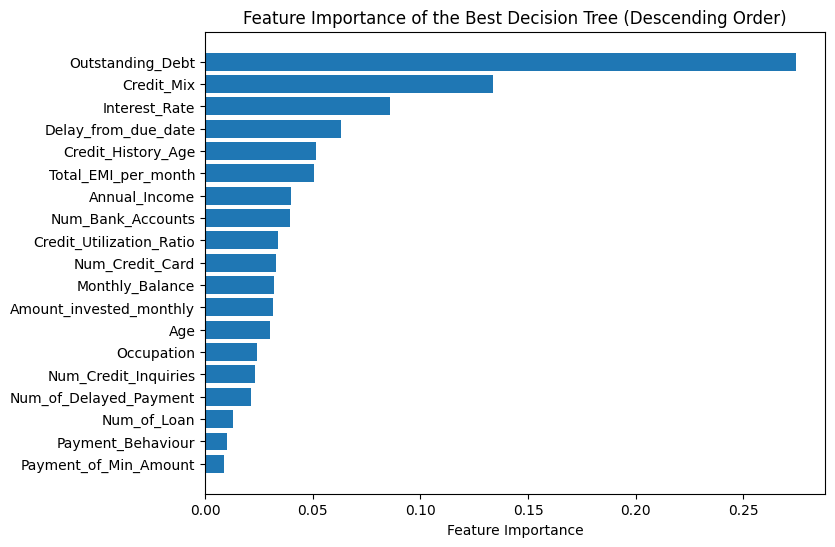

In [17]:
feature_names = df.drop(columns=['Credit_Score'], axis=1).columns
feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_feature_names = feature_names[sorted_idx]
sorted_importances = feature_importances[sorted_idx]
plt.figure(figsize=(8, 6))
plt.barh(range(len(sorted_importances)), sorted_importances, align='center')
plt.yticks(range(len(sorted_importances)), sorted_feature_names)
plt.xlabel('Feature Importance')
plt.title('Feature Importance of the Best Decision Tree (Descending Order)')
plt.gca().invert_yaxis()
plt.show()

In [28]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, 
                           scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {best_params}")

y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}",mse)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


C:\Users\asus\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [17:14:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.78 0.45829705728713216


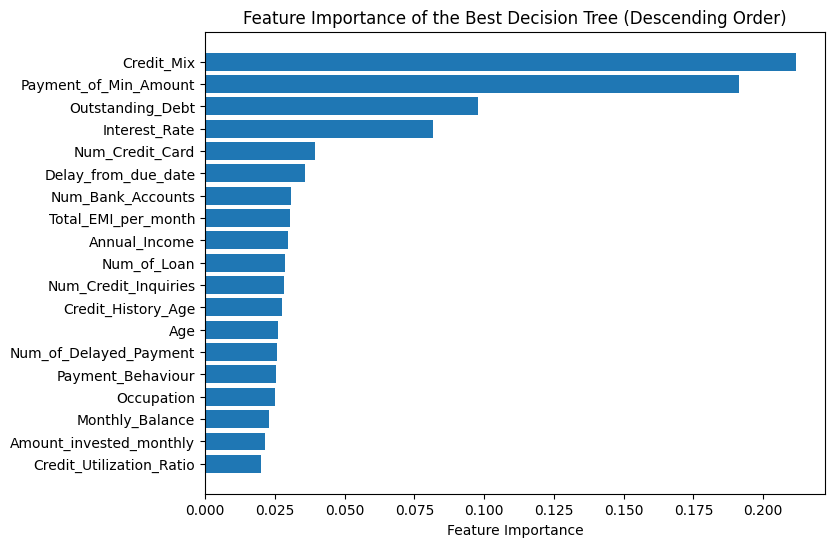

In [29]:
feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_feature_names = feature_names[sorted_idx]
sorted_importances = feature_importances[sorted_idx]
plt.figure(figsize=(8, 6))
plt.barh(range(len(sorted_importances)), sorted_importances, align='center')
plt.yticks(range(len(sorted_importances)), sorted_feature_names)
plt.xlabel('Feature Importance')
plt.title('Feature Importance of the Best Decision Tree (Descending Order)')
plt.gca().invert_yaxis()
plt.show()